<a href="https://colab.research.google.com/github/aumer1800/EmailSpamDetector/blob/main/Email_spam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload kaggle json file

In [ ]:
from google.colab import files
upload = files.upload()

Saving kaggle (2).json to kaggle (2).json


Download dataset directly from kaggle


In [ ]:
# Install Kaggle if needed
!pip install -q kaggle

# Download the dataset
!kaggle datasets download -d uciml/sms-spam-collection-dataset

Dataset URL: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
License(s): unknown
100% 211k/211k [00:00<00:00, 704kB/s]



Unzip the dataset

In [ ]:
import zipfile

with zipfile.ZipFile("sms-spam-collection-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("spam-collection")

Check data structure

In [ ]:
import os
for root,dirs ,files in os.walk("spam-collection"):
  for file in files:
    print(os.path.join(root , file))

spam-collection/spam.csv


Load the dataset

In [ ]:
import pandas as pd

df = pd.read_csv(
    "spam-collection/spam.csv",
    encoding="latin-1"
)

# Data Cleaning


In [ ]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


Remove extra columns

In [ ]:
df =df[['v1', 'v2']]

In [ ]:
df.head(3)

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...


Rename the columns

In [ ]:
df.columns = ['label', 'message']

In [ ]:
df.shape

(5572, 2)

In [ ]:
df.isnull().sum()

,0
label,0
message,0


Check duplicate values

In [ ]:
df.duplicated().sum()

np.int64(0)

Remove duplicate values


In [ ]:
df = df.drop_duplicates()

Check data information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5169 non-null   object
 1   message  5169 non-null   object
dtypes: object(2)
memory usage: 121.1+ KB


In [ ]:
df['label'].value_counts()

,count
label,
ham,4516
spam,653


In [ ]:
df['label'].unique()

array(['ham', 'spam'], dtype=object)

In [ ]:
class_percentages = df['label'].value_counts(normalize=True) * 100

print(class_percentages.round(2))

label
ham     87.37
spam    12.63
Name: proportion, dtype: float64


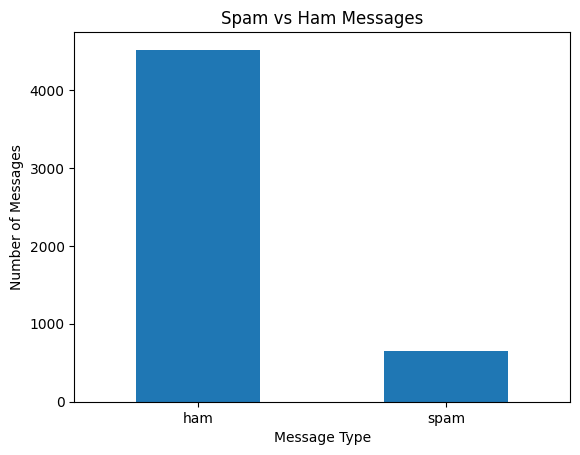

In [ ]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')

plt.title('Spam vs Ham Messages')
plt.xlabel('Message Type')
plt.ylabel('Number of Messages')
plt.xticks(rotation=0)
plt.show()

Check empty message

In [ ]:
(df['message'].str.strip() == '').sum()

np.int64(0)

# Clean the message


*  we use clean_message because TF-IDF works better when unnecessary text noise has been removed.



In [ ]:
!pip install -q contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.8/114.8 kB 7.9 MB/s eta 0:00:00


In [ ]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
import re
import contractions
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Expand contractions
    text = contractions.fix(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return ' '.join(words)

In [ ]:
df['clean_message'] = df['message'].apply(preprocess_text)

# Train/Test Split


In [ ]:
from sklearn.model_selection import train_test_split
X = df['clean_message']
Y = df['label']

X_train , X_test ,Y_train, Y_test = train_test_split(
    X , Y , test_size = 0.2 , random_state =42 , stratify = Y
)

print("Training sample", len(X_train))
print("Testing sample", len(X_test))

Training sample 4135
Testing sample 1034


# Feature extraction using TF-IDF Vectorizer

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Create the TF-IDF Vectorizer
tfidf = TfidfVectorizer()
# Fit TF-IDF ONLY on training data
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)



In [ ]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4135, 7135)
Testing TF-IDF shape: (1034, 7135)


# 1. Multinomial Naive Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB
# Create and train the model
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf,Y_train)

MultinomialNB()

# Make & Check Prediction

In [ ]:
y_pred_nb = nb_model.predict(X_test_tfidf)
print(y_pred_nb[:20])

['ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham'
 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham']


# Evaluate the model

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [ ]:
accuracy_nb = accuracy_score(Y_test, y_pred_nb)

precision_nb = precision_score(
    Y_test,
    y_pred_nb,
    pos_label='spam'
)

recall_nb = recall_score(
    Y_test,
    y_pred_nb,
    pos_label='spam'
)

f1_nb = f1_score(
    Y_test,
    y_pred_nb,
    pos_label='spam'
)

print("Multinomial Naive Bayes")
print("-----------------------")
print("Accuracy :", accuracy_nb)
print("Precision:", precision_nb)
print("Recall   :", recall_nb)
print("F1-score :", f1_nb)

Multinomial Naive Bayes
-----------------------
Accuracy : 0.9632495164410058
Precision: 0.9894736842105263
Recall   : 0.7175572519083969
F1-score : 0.831858407079646


In [ ]:
print(classification_report(Y_test, y_pred_nb))

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       903
        spam       0.99      0.72      0.83       131

    accuracy                           0.96      1034
   macro avg       0.98      0.86      0.91      1034
weighted avg       0.96      0.96      0.96      1034



# Confusion Matrix

In [ ]:
cm_nb = confusion_matrix(Y_test, y_pred_nb)

print(cm_nb)

[[902   1]
 [ 37  94]]


Visualization

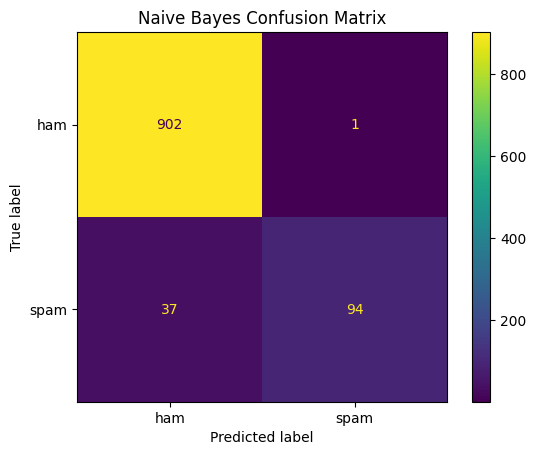

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=['ham', 'spam']
).plot()

plt.title("Naive Bayes Confusion Matrix")
plt.show()

# 2. Linear SVM


In [ ]:
from sklearn.svm import LinearSVC

In [ ]:
# create and train the model
svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train_tfidf, Y_train)

LinearSVC(random_state=42)

In [ ]:
# make prediction
y_pred_svm = svm_model.predict(X_test_tfidf)

Calculate Evaluation matrix

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

accuracy_svm = accuracy_score(Y_test, y_pred_svm)

precision_svm = precision_score(
    Y_test,
    y_pred_svm,
    pos_label='spam'
)

recall_svm = recall_score(
    Y_test,
    y_pred_svm,
    pos_label='spam'
)

f1_svm = f1_score(
    Y_test,
    y_pred_svm,
    pos_label='spam'
)

print("Linear SVM")
print("----------")
print("Accuracy :", accuracy_svm)
print("Precision:", precision_svm)
print("Recall   :", recall_svm)
print("F1-score :", f1_svm)

Linear SVM
----------
Accuracy : 0.9738878143133463
Precision: 0.956140350877193
Recall   : 0.8320610687022901
F1-score : 0.889795918367347


In [ ]:
# classification matrix
print(classification_report(Y_test, y_pred_svm))

              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       903
        spam       0.96      0.83      0.89       131

    accuracy                           0.97      1034
   macro avg       0.97      0.91      0.94      1034
weighted avg       0.97      0.97      0.97      1034



In [ ]:
# confusion matrix
cm_svm = confusion_matrix(Y_test, y_pred_svm)

print(cm_svm)

[[898   5]
 [ 22 109]]


Visualize confusion matrix

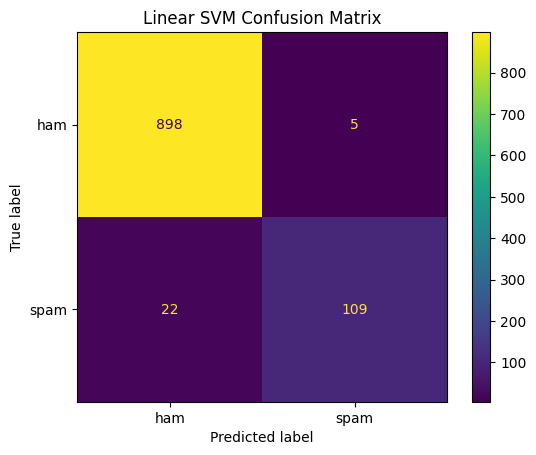

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=['ham', 'spam']
).plot()

plt.title("Linear SVM Confusion Matrix")
plt.show()

# 3. Comparison


*   Between Multinomial Naive Bayes & Linear SVM




In [ ]:
comparison = pd.DataFrame({
    'Model': ['Multinomial Naive Bayes', 'Linear SVM'],
    'Accuracy': [accuracy_nb, accuracy_svm],
    'Precision': [precision_nb, precision_svm],
    'Recall': [recall_nb, recall_svm],
    'F1-Score': [f1_nb, f1_svm]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.963250,0.989474,0.717557,0.831858
1,Linear SVM,0.973888,0.956140,0.832061,0.889796


# Discussion:

Ques: Why is recall particularly important for spam detection?

Ans :Recall is particularly important in spam detection because it measures how many of the actual spam messages are correctly identified by the classifier.

In this project, the spam class is the positive class. A false negative occurs when an actual spam message is incorrectly classified as a legitimate (ham) message. A high number of false negatives means that many spam messages can reach the user's inbox.

For example, if there are 100 actual spam messages and the classifier correctly identifies 80 of them, the spam recall is 80%.

Therefore, a higher spam recall is desirable because it helps the system detect more of the actual spam messages. However, precision is also important because incorrectly marking legitimate messages as spam can cause important messages to be lost.

In this project, Linear SVM achieved a spam recall of 83.21%, compared with 71.76% for Multinomial Naive Bayes. Therefore, Linear SVM is preferred because it detects a larger proportion of actual spam messages while maintaining a high precision of 95.61%.


# Bonus — WordCloud

In [ ]:
!pip install -q wordcloud

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

Create spam and ham text

In [ ]:
spam_text = ' '.join(
    df[df['label'] == 'spam']['clean_message']
)

ham_text = ' '.join(
    df[df['label'] == 'ham']['clean_message']
)

WordCloud for Spam

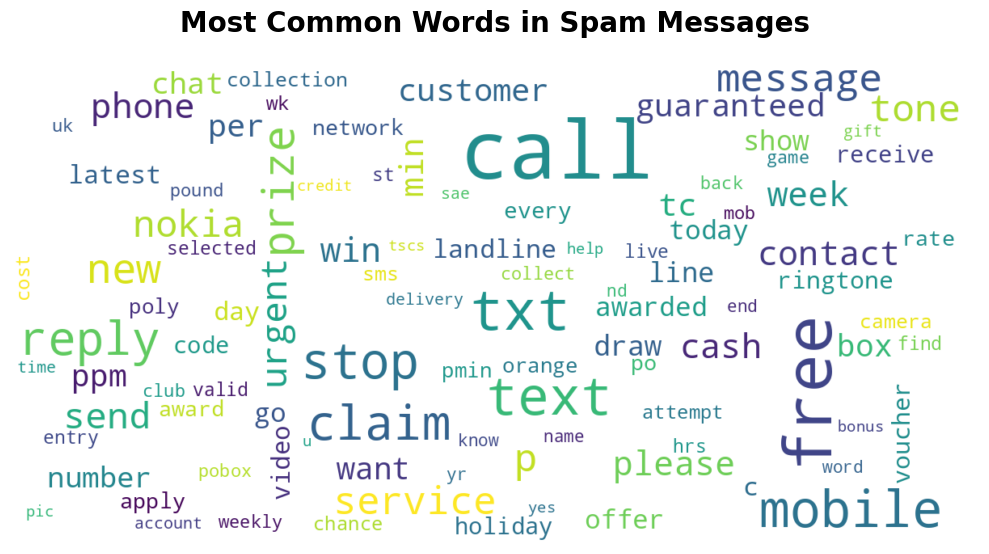

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

spam_wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=100,
    min_font_size=10,
    max_font_size=100,
    collocations=False,
    margin=5
).generate(spam_text)

plt.figure(figsize=(10, 7))

plt.imshow(spam_wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title(
    'Most Common Words in Spam Messages',
    fontsize=20,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()

WordCloud for Ham

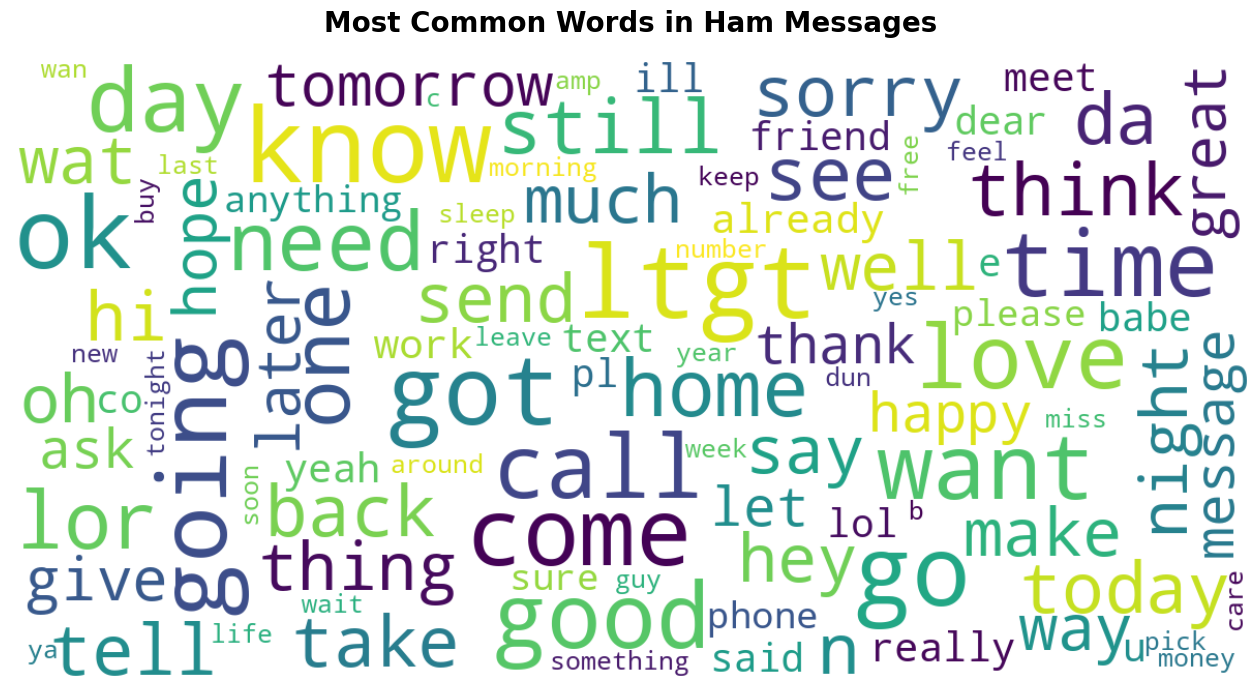

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

ham_wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=100,
    min_font_size=10,
    max_font_size=100,
    collocations=False,
    margin=5
).generate(ham_text)

plt.figure(figsize=(14, 7))

plt.imshow(ham_wordcloud, interpolation='bilinear')

plt.axis('off')
plt.title(
    'Most Common Words in Ham Messages',
    fontsize=20,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()

# WordCloud Analysis

The WordCloud visualizations show the most frequently occurring words in spam and ham messages. Spam messages contain words commonly associated with promotions, prizes, offers, and urgent actions, while ham messages contain more conversational and personal vocabulary.

These visualizations provide an intuitive understanding of the differences between the two classes. However, WordClouds show word frequency and do not directly indicate which words are most important for classification. TF-IDF features are used by the machine-learning models to represent the text numerically.
